In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.interpolate import interp1d


def extract_positions(observations):
    # extracts the positions of the agents and entities from the observations
    agent_positions = []
    entities_positions = []
    for obs in observations:
        # 2 + 2 + 2 * 2 + 3 * 2 + 3 * 2 = 20
        agent_velocity = np.array([obs[0], obs[1]])
        agent_position = np.array([obs[2], obs[3]])
        entity_positions = np.array([obs[4:8]]).reshape(2, 2) + agent_position
        other_positions = np.array(obs[8:14]).reshape(3, 2) + agent_position
        other_velocities = np.array(obs[14:])
        agent_positions.append(agent_position)
        entities_positions.append(entity_positions) # only keep the entity positions for one of the agents
    
    # reshape the positions to be (num_timesteps, num_agents, 2)
    # and the entities_positions to be (num_timesteps, num_entities, 2)
    agent_positions = np.array(agent_positions).reshape(-1, 4, 2)
    entities_positions = np.array(entities_positions).reshape(-1, 2, 2)[::4]
    # join the positions and entities_positions to be (num_timesteps, num_agents + num_entities, 2)
    positions = np.concatenate((agent_positions, entities_positions), axis=1)
    return positions


# def extract_positions_and_velocities(observations):
#     positions = []
#     entities_positions = []
#     velocities = []
#     for obs in observations:
#         # 2 + 2 + 2 * 2 + 3 * 2 + 3 * 2 = 20
#         agent_velocity = np.array([obs[0], obs[1]])
#         agent_position = np.array([obs[2], obs[3]])
#         entity_positions = np.array([obs[4:8]]).reshape(2, 2) + agent_position
#         other_positions = np.array(obs[8:14]).reshape(3, 2) + agent_position
#         other_velocities = np.array(obs[14:])
#         positions.append(agent_position)
#         entities_positions.append(entity_positions)
#         velocities.append(agent_velocity)
#     return np.array(positions), np.array(entities_positions), np.array(velocities)


def interpolate_positions(positions, num_interpolation_points):
    # interpolate the positions to make the animation smoother
    # every 25 timesteps will be interpolated to 25 * num_interpolation_points timesteps
    # there will ne no interpolation between these batches of 25 timesteps
    num_timesteps, num_agents, _ = positions.shape
    # separate the positions into batches of 25 timesteps
    positions = positions.reshape(-1, 25, num_agents, 2)
    # interpolate the positions in each batch
    positions_interp = np.zeros((positions.shape[0], (25 - 1) * num_interpolation_points + 1, num_agents, 2))
    for i in range(positions.shape[0]):
        positions_interp[i] = interpolate_positions_batch(positions[i], num_interpolation_points)
    # reshape the interpolated positions to be (num_timesteps, num_agents, 2)
    positions_interp = positions_interp.reshape(-1, num_agents, 2)
    return positions_interp

def interpolate_positions_batch(positions, num_interpolation_points):
    num_timesteps, num_agents, _ = positions.shape
    x = np.arange(num_timesteps)
    x_interp = np.linspace(0, num_timesteps - 1, (num_timesteps - 1) * num_interpolation_points + 1)
    positions_interp = np.zeros((x_interp.shape[0], num_agents, 2))

    for agent_id in range(num_agents):
        for axis in range(2):
            interp_func = interp1d(x, positions[:, agent_id, axis], kind='linear')
            positions_interp[:, agent_id, axis] = interp_func(x_interp)
    
    return positions_interp




def interp_entities(entities, num_interpolation_points):
    num_timesteps, num_entities, _ = entities.shape
    x = np.arange(num_timesteps)
    x_interp = np.linspace(0, num_timesteps - 1, (num_timesteps - 1) * num_interpolation_points + 1)
    entities_interp = np.zeros((x_interp.shape[0], num_entities, 2))

    for entity_id in range(num_entities):
        for axis in range(2):
            interp_func = interp1d(x, entities[:, entity_id, axis], kind='linear')
            entities_interp[:, entity_id, axis] = interp_func(x_interp)
    
    return entities_interp

In [2]:
# Load the h5 dataset
file_path = '../data.h5'
df_whole = pd.read_hdf(file_path)

In [30]:
df_whole.keys()

Index(['obs', 'new_obs', 'actions', 'prev_actions', 'rewards', 'prev_rewards',
       'dones', 'infos', 't', 'eps_id', 'unroll_id', 'agent_index', 'vf_preds',
       'action_dist_inputs', 'action_prob', 'action_logp', 'advantages',
       'value_targets', 'policy_name', 'eval_episode'],
      dtype='object')

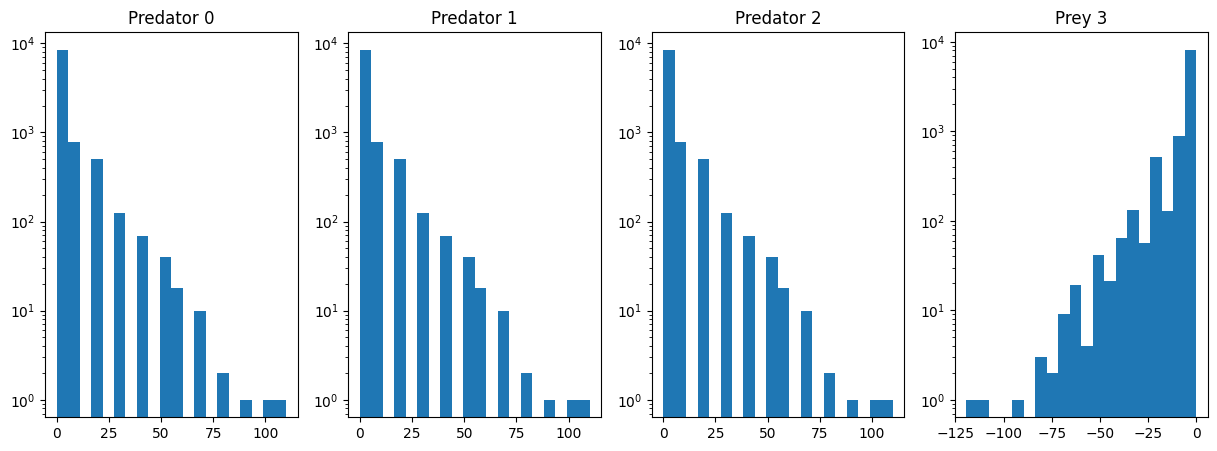

In [149]:
# separate df_whole into one dataframe per agent
df_agent_0 = df_whole[df_whole['agent_index'] == 0]
df_agent_1 = df_whole[df_whole['agent_index'] == 1]
df_agent_2 = df_whole[df_whole['agent_index'] == 2]
df_agent_3 = df_whole[df_whole['agent_index'] == 3]

# sum the rewards of each agent across episodes
rewards_agent_0 = df_agent_0.groupby('eps_id')['rewards'].sum().sort_values(ascending=False)
rewards_agent_1 = df_agent_1.groupby('eps_id')['rewards'].sum().sort_values(ascending=False)
rewards_agent_2 = df_agent_2.groupby('eps_id')['rewards'].sum().sort_values(ascending=False)
rewards_agent_3 = df_agent_3.groupby('eps_id')['rewards'].sum().sort_values(ascending=False)

# plot the rewards of each agent in four separate histograms
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].hist(rewards_agent_0, bins=20)
axes[0].set_title('Predator 0')
axes[1].hist(rewards_agent_1, bins=20)
axes[1].set_title('Predator 1')
axes[2].hist(rewards_agent_2, bins=20)
axes[2].set_title('Predator 2')
axes[3].hist(rewards_agent_3, bins=20)
axes[3].set_title('Prey 3')
# set y axis to be log scale
axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[2].set_yscale('log')
axes[3].set_yscale('log')

plt.show()


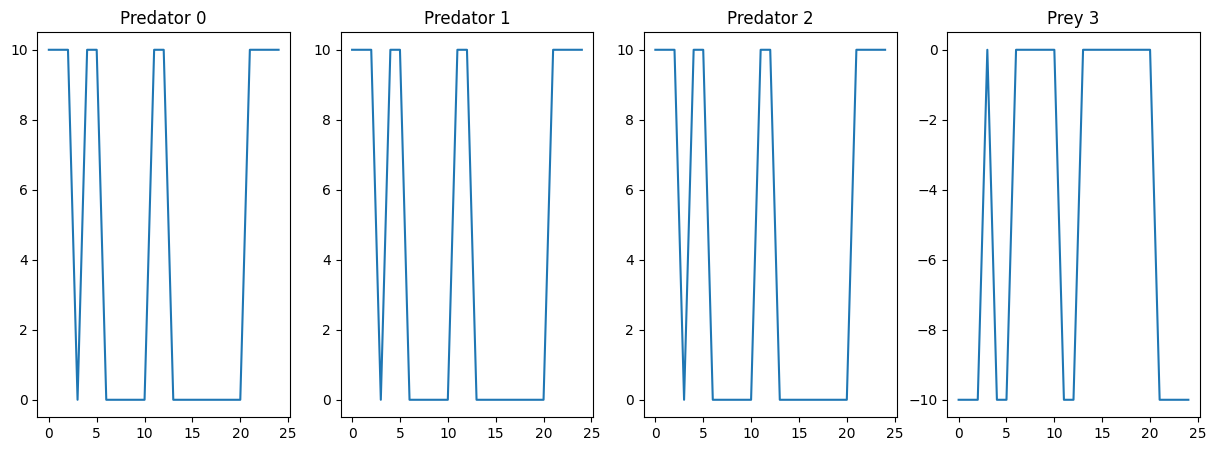

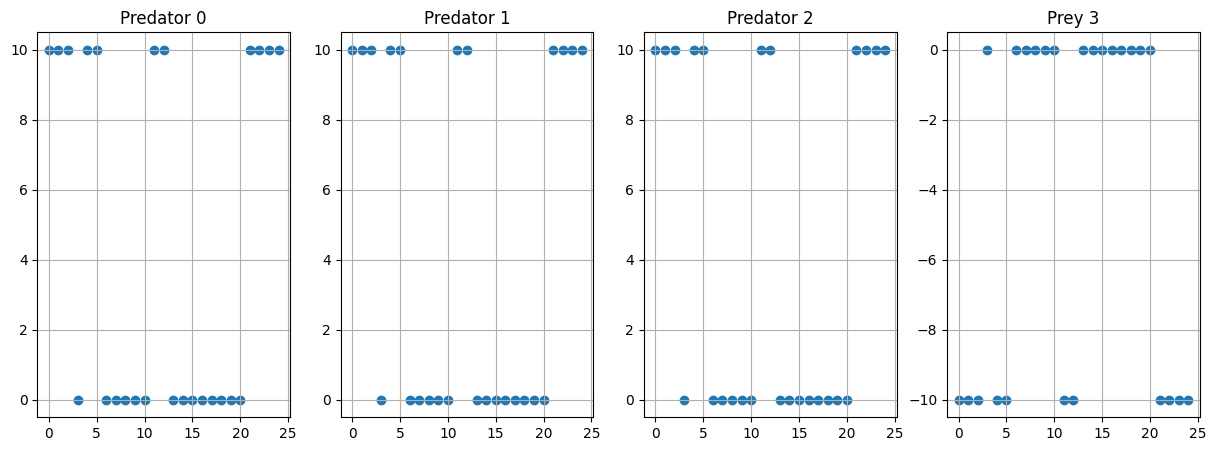

In [155]:
idxmax_reward_agent_0 = rewards_agent_0.idxmax()
max_reward_eps = df_whole[df_whole['eps_id'] == rewards_agent_0.idxmax()]
# plot the reward across timesteps for the episode with the highest reward, one line per agent
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].plot(max_reward_eps[max_reward_eps['agent_index'] == 0]['t'], max_reward_eps[max_reward_eps['agent_index'] == 0]['rewards'])
axes[0].set_title('Predator 0')
axes[1].plot(max_reward_eps[max_reward_eps['agent_index'] == 1]['t'], max_reward_eps[max_reward_eps['agent_index'] == 1]['rewards'])
axes[1].set_title('Predator 1')
axes[2].plot(max_reward_eps[max_reward_eps['agent_index'] == 2]['t'], max_reward_eps[max_reward_eps['agent_index'] == 2]['rewards'])
axes[2].set_title('Predator 2')
axes[3].plot(max_reward_eps[max_reward_eps['agent_index'] == 3]['t'], max_reward_eps[max_reward_eps['agent_index'] == 3]['rewards'])
axes[3].set_title('Prey 3')
plt.show()


fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].scatter(max_reward_eps[max_reward_eps['agent_index'] == 0]['t'], max_reward_eps[max_reward_eps['agent_index'] == 0]['rewards'])
axes[0].set_title('Predator 0')
axes[1].scatter(max_reward_eps[max_reward_eps['agent_index'] == 1]['t'], max_reward_eps[max_reward_eps['agent_index'] == 1]['rewards'])
axes[1].set_title('Predator 1')
axes[2].scatter(max_reward_eps[max_reward_eps['agent_index'] == 2]['t'], max_reward_eps[max_reward_eps['agent_index'] == 2]['rewards'])
axes[2].set_title('Predator 2')
axes[3].scatter(max_reward_eps[max_reward_eps['agent_index'] == 3]['t'], max_reward_eps[max_reward_eps['agent_index'] == 3]['rewards'])
axes[3].set_title('Prey 3')
# add grid lines
axes[0].grid()
axes[1].grid()
axes[2].grid()
axes[3].grid()





In [163]:
rewards_agent_0.index[0:2]

Int64Index([446696393, 1402306937], dtype='int64', name='eps_id')

In [250]:
plotting_eps = rewards_agent_0.index[0:2]

df = df_whole[df_whole.eps_id.isin(plotting_eps)]
df.sort_values(by=['eps_id', 't', 'agent_index'], inplace=True)


num_episodes = len(plotting_eps)
observations = df['obs'].values
actions = df['actions'].values
agent_ids = df['agent_index'].values
timesteps = df['t'].values
# keep every 4th timestep
timesteps = timesteps[::4]
rewards = df['rewards'].values
# reshape rewards to have four columns
rewards = np.reshape(rewards, (-1, 4))
# only keep one column of rewards (it's a zero-sum game)
rewards = rewards[:, 0]

positions = extract_positions(observations)

num_interpolation_points = 10
positions_interp = interpolate_positions(positions, num_interpolation_points)
# interpolate the timestep values
timesteps_interp = np.linspace(0, len(timesteps)//num_episodes - 1, ((len(timesteps)//num_episodes - 1) * num_interpolation_points + 1))
timesteps_interp = np.concatenate([timesteps_interp, timesteps_interp])

# interpolate the rewards by backfilling
rewards_interp = np.repeat(rewards, num_interpolation_points)

C:\Users\Andrew Williams\AppData\Local\Temp\ipykernel_14124\3795260601.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by=['eps_id', 't', 'agent_index'], inplace=True)


In [259]:
rewards

array([10., 10., 10.,  0., 10., 10.,  0.,  0.,  0.,  0.,  0., 10., 10.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 10., 10., 10., 10.,  0.,
        0., 10., 10., 10., 10., 10., 10.,  0.,  0., 10., 10.,  0.,  0.,
        0.,  0.,  0.,  0., 10.,  0.,  0., 10.,  0.,  0.,  0.])

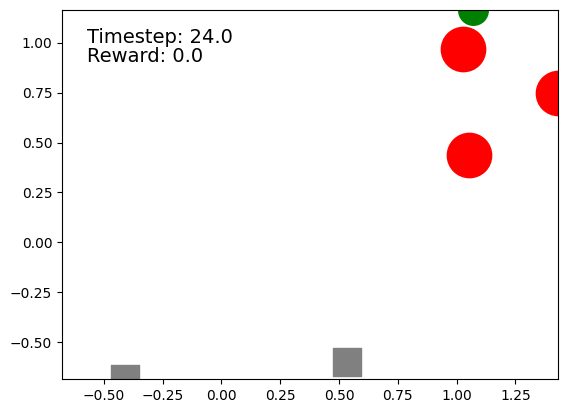

In [260]:
# print current time
import datetime

def update_plot(frame, positions, agent_ids, scatters, timesteps, rewards_interp):
    # for agent_id, scatter in zip(agent_ids, scatters[0:4]):
    #     scatter.set_offsets(positions[frame, agent_id])
    for agent_id, scatter in enumerate(scatters):
        scatter.set_offsets(positions[frame, agent_id])
    # update timestep_text to show the current timestep with one decimal place
    timestep_text.set_text(f'Timestep: {timesteps[frame]:.1f}')
    reward_text.set_text(f'Reward: {rewards_interp[frame]:.1f}')
    
    return scatters


# 0.075 for adversary, 0.05 for prey
# Set up the plot
fig, ax = plt.subplots()
ax.set_xlim(positions_interp[:,:,0].min(), positions_interp[:,:,0].max())
ax.set_ylim(positions_interp[:,:,1].min(), positions_interp[:,:,1].max())
scatters = [ax.scatter(positions_interp[0, agent_id, 0], positions_interp[0, agent_id, 1], s=np.pi * 18**2, color='red', label=f'Predator {agent_id}') for agent_id in [0,1,2]]
# make the scatter for agent 3 a bigger dot
scatters.append(ax.scatter(positions_interp[0, 3, 0], positions_interp[0, 3, 1], label='Prey', s=np.pi * 12**2, color='green'))
# make the scatter for the entities a square instead of a circle
scatters.append(ax.scatter(positions_interp[0, 4, 0], positions_interp[0, 4, 1], label='Entity 1', marker='s', s=400, color='gray'))
scatters.append(ax.scatter(positions_interp[0, 5, 0], positions_interp[0, 5, 1], label='Entity 2', marker='s', s=400, color='gray'))
# ax.legend()
# add the timesteps to the plot
timestep_text  = ax.text(0.05, 0.95, f'Timestep: {timesteps_interp[0]}', transform=ax.transAxes, fontsize=14, verticalalignment='top')
reward_text = ax.text(0.05, 0.90, f'Reward: {rewards_interp[0]}', transform=ax.transAxes, fontsize=14, verticalalignment='top')

# Create an animation from the data
frames = positions_interp.shape[0]
num_timesteps = observations.shape[0]
ani = animation.FuncAnimation(fig, update_plot, frames=frames, fargs=(positions_interp, agent_ids, scatters, timesteps_interp, rewards_interp), interval=1000)

# Save the animation to a file (optional), add the current time to the filename
datetime_str = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
ani.save(f'animation_{datetime_str}.mp4', writer='ffmpeg', fps=25)

# Display the animation
plt.show()